# Notebook 2: Synthetic Patterns — Controlled Data Experiments

Isolate how Migas 1.5 responds to different time series shapes × different text signals, using fully controlled synthetic data.

**Experiments:**
- **2A** — Text Sensitivity Matrix (8 patterns × 6 prompts = 48 forecasts)
- **2B** — Convex Weight Patterns (does the model trust Chronos more for certain shapes?)
- **2C** — Magnitude Sensitivity (does text influence scale with signal intensity?)
- **2D** — Scale Sensitivity (is the model scale-invariant after normalization?)
- **2E** — Context Length Sensitivity (how does context length affect text vs. Chronos balance?)

**Key findings from Notebook 1:**
- Factual section is **16.2×** more influential than predictive signals
- Convex weights w ∈ [0.79, 0.96] — model heavily trusts Chronos
- Gate is very sparse (mean ≈ 0.11, only ~11% of dims > 0.5)
- FinBERT differentiates factual content (rich vs generic) far more than sentiment (bull vs bear)

In [1]:
import sys, os
sys.path.insert(0, "synthefy-migas/src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from migaseval import MigasPipeline
from experiment_utils import (
    MigasInternalsExtractor,
    SYNTHETIC_PATTERNS,
    generate_synthetic_series,
    describe_series,
    build_summary,
    text_shift,
    plot_convex_weights,
    plot_forecast_comparison,
    plot_heatmap,
    decompose_forecast,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
pipeline = MigasPipeline.from_pretrained("Synthefy/migas-1.5", device="cpu")
extractor = MigasInternalsExtractor(pipeline)

PRED_LEN = 8

/opt/miniconda3/envs/tft_forecasting/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Chronos-2 on device: cpu
Initialized univariate model: chronos


## Synthetic Series Generator

8 canonical patterns (50 steps, values in [0, 1000]):

| Pattern | Description |
|---------|-------------|
| **Constant** | Flat line at 500 |
| **Trend Up** | Steady increase 200 → 800 |
| **Trend Down** | Steady decrease 800 → 200 |
| **Sine Wave** | Periodic oscillation (period ~12) |
| **Random Walk** | Gaussian increments from midpoint |
| **Volatile** | Large random jumps (high CV) |
| **Intermittent** | Mostly near-zero with occasional spikes |
| **Regime Change** | Flat at 300 for 30 steps, then jumps to 700 |

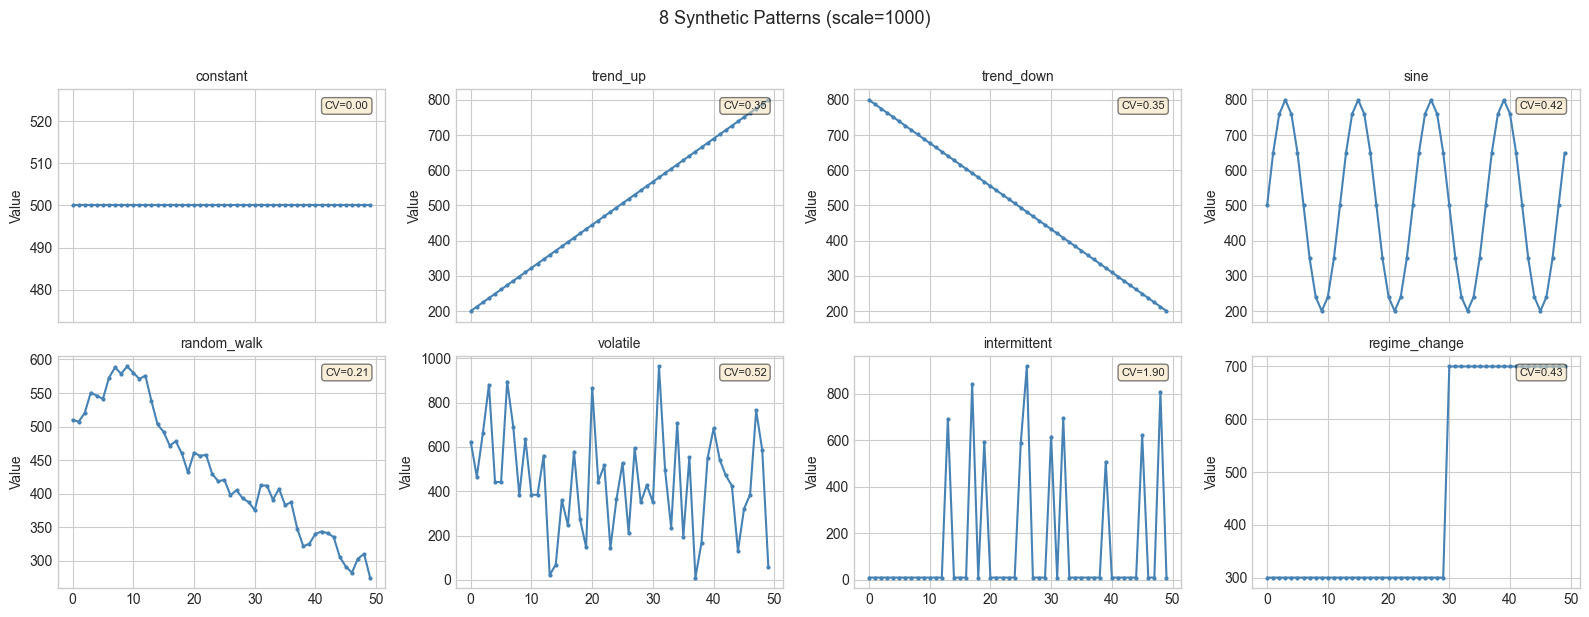

                     mean         std    min         max   CV
constant       500.000000    0.000000  500.0  500.000000  0.0
trend_up       500.000000  176.699997  200.0  800.000000  0.4
trend_down     500.000000  176.699997  200.0  800.000000  0.4
sine           503.000000  208.899994  200.0  800.000000  0.4
random_walk    434.299988   93.099998  274.5  589.599976  0.2
volatile       443.600006  231.100006   10.1  963.099976  0.5
intermittent   145.500000  276.500000   10.0  916.599976  1.9
regime_change  460.000000  196.000000  300.0  700.000000  0.4


In [3]:
# Generate and visualize all 8 patterns
series_dict = {pat: generate_synthetic_series(pat, length=50, scale=1000.0)
               for pat in SYNTHETIC_PATTERNS}

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True)
for ax, (pat, s) in zip(axes.flat, series_dict.items()):
    ax.plot(s, "o-", ms=2, color="steelblue")
    ax.set_title(pat, fontsize=10)
    ax.set_ylabel("Value")
    cv = s.std() / s.mean() if s.mean() > 0 else 0
    ax.text(0.95, 0.95, f"CV={cv:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, bbox=dict(boxstyle="round", fc="wheat", alpha=0.5))
plt.suptitle("8 Synthetic Patterns (scale=1000)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Stats table
stats = pd.DataFrame({
    pat: {"mean": s.mean(), "std": s.std(), "min": s.min(), "max": s.max(),
          "CV": s.std() / s.mean() if s.mean() > 0 else 0}
    for pat, s in series_dict.items()
}).T.round(1)
print(stats.to_string())

## Prompt Battery

For each pattern, 6 standardized prompts:

| ID | Factual | Predictive |
|----|---------|------------|
| **P1** | Accurate | "Expect continuation" |
| **P2** | Accurate | "Sharp reversal, 50% opposite move" |
| **P3** | Accurate | "Extreme surge, 200% increase" |
| **P4** | Misleading (claims uptrend) | "Expect continuation" |
| **P5** | Empty | Empty |
| **P6** | Accurate | Contradictory ("both increase and decrease likely") |

In [4]:
# Define the prompt battery
PROMPT_IDS = ["P1_continue", "P2_reversal", "P3_surge", "P4_misleading", "P5_empty", "P6_contradict"]

PREDICTIVE_TEXTS = {
    "P1_continue":   "Expect continuation of recent patterns with similar levels and no major shifts.",
    "P2_reversal":   "Sharp reversal expected, 50% move in opposite direction from recent trend.",
    "P3_surge":      "Extreme surge expected, 200% increase from current levels imminent.",
    "P4_misleading": "Expect continuation of recent patterns.",  # paired with misleading factual
    "P5_empty":      "",
    "P6_contradict": "Both sharp increase and sharp decrease equally likely. Extreme volatility expected.",
}

MISLEADING_FACTUAL = (
    "The series shows a strong and consistent upward trend with steadily "
    "increasing values and no signs of leveling off."
)


def build_prompt_battery(values: np.ndarray) -> dict:
    """Build the 6-prompt battery for a given series."""
    accurate = describe_series(values)
    prompts = {}
    for pid in PROMPT_IDS:
        if pid == "P4_misleading":
            prompts[pid] = build_summary(MISLEADING_FACTUAL, PREDICTIVE_TEXTS[pid])
        elif pid == "P5_empty":
            prompts[pid] = build_summary("", "")
        else:
            prompts[pid] = build_summary(accurate, PREDICTIVE_TEXTS[pid])
    return prompts


# Show example prompt for the constant pattern
example_prompts = build_prompt_battery(series_dict["constant"])
for pid, text in example_prompts.items():
    print(f"=== {pid} ===")
    print(text[:120] + "..." if len(text) > 120 else text)
    print()

=== P1_continue ===
FACTUAL SUMMARY:
The series spans 50 observations ranging from 500.0 to 500.0. Mean value is 500.0 with standard deviati...

=== P2_reversal ===
FACTUAL SUMMARY:
The series spans 50 observations ranging from 500.0 to 500.0. Mean value is 500.0 with standard deviati...

=== P3_surge ===
FACTUAL SUMMARY:
The series spans 50 observations ranging from 500.0 to 500.0. Mean value is 500.0 with standard deviati...

=== P4_misleading ===
FACTUAL SUMMARY:
The series shows a strong and consistent upward trend with steadily increasing values and no signs of l...

=== P5_empty ===
FACTUAL SUMMARY:


PREDICTIVE SIGNALS:


=== P6_contradict ===
FACTUAL SUMMARY:
The series spans 50 observations ranging from 500.0 to 500.0. Mean value is 500.0 with standard deviati...



## Experiment 2A - Text Sensitivity Matrix

Run all 8 patterns × 6 prompts = **48 forecasts**. For each, compute `text_shift = MAE(migas, chronos)` - how far text pushed the forecast from the univariate baseline.

**Key question:** Which patterns are most/least susceptible to text conditioning?

In [5]:
# Run all 48 forecasts and collect results
all_results = {}  # (pattern, prompt_id) -> extractor results

for pat in SYNTHETIC_PATTERNS:
    values = series_dict[pat]
    prompts = build_prompt_battery(values)
    for pid, summary in prompts.items():
        key = (pat, pid)
        all_results[key] = extractor.run(values, summary, pred_len=PRED_LEN)
    print(f"  {pat}: done ({len(prompts)} prompts)")

print(f"\nTotal runs: {len(all_results)}")

  constant: done (6 prompts)
  trend_up: done (6 prompts)
  trend_down: done (6 prompts)
  sine: done (6 prompts)
  random_walk: done (6 prompts)
  volatile: done (6 prompts)
  intermittent: done (6 prompts)
  regime_change: done (6 prompts)

Total runs: 48


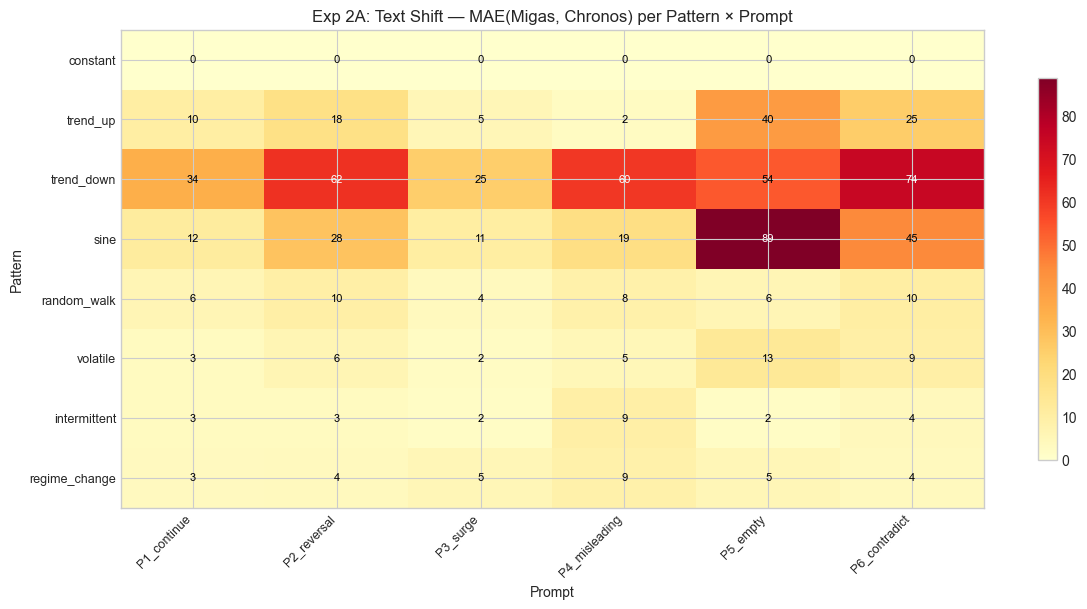


Text shift summary (mean across prompts):
trend_down      51.6
sine            33.8
trend_up        16.9
random_walk      7.2
volatile         6.5
regime_change    5.0
intermittent     3.9
constant         0.0

Text shift summary (mean across patterns):
P1_continue      8.8
P2_reversal     16.3
P3_surge         6.8
P4_misleading   14.1
P5_empty        26.1
P6_contradict   21.5


In [6]:
# Build text_shift matrix: patterns × prompts
shift_matrix = pd.DataFrame(index=SYNTHETIC_PATTERNS, columns=PROMPT_IDS, dtype=float)

for pat in SYNTHETIC_PATTERNS:
    # Chronos baseline is the same for all prompts on the same pattern
    chronos_fc = all_results[(pat, PROMPT_IDS[0])]["chronos_forecast"]
    for pid in PROMPT_IDS:
        migas_fc = all_results[(pat, pid)]["forecast"]
        shift_matrix.loc[pat, pid] = text_shift(migas_fc, chronos_fc)

fig, ax = plot_heatmap(shift_matrix, title="Exp 2A: Text Shift — MAE(Migas, Chronos) per Pattern × Prompt")
ax.set_xlabel("Prompt")
ax.set_ylabel("Pattern")
plt.show()

print("\nText shift summary (mean across prompts):")
print(shift_matrix.mean(axis=1).sort_values(ascending=False).to_string(float_format="{:.1f}".format))
print("\nText shift summary (mean across patterns):")
print(shift_matrix.mean(axis=0).to_string(float_format="{:.1f}".format))

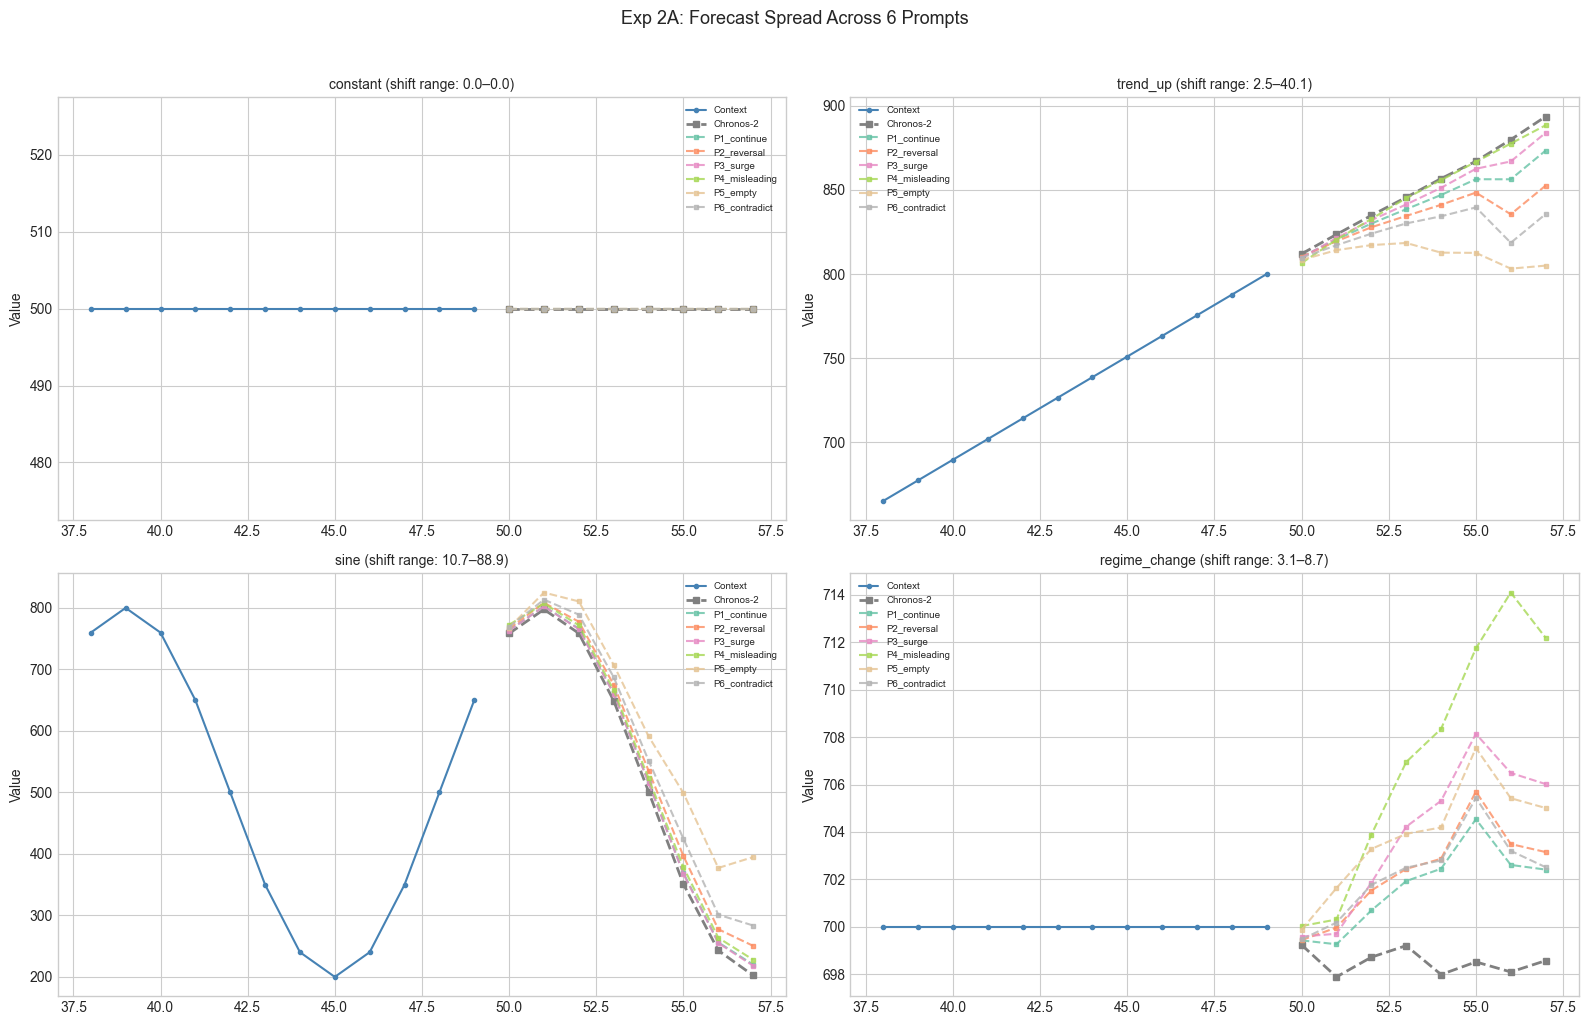

In [7]:
# Visualize forecasts for 4 representative patterns, all 6 prompts each
rep_patterns = ["constant", "trend_up", "sine", "regime_change"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, pat in zip(axes.flat, rep_patterns):
    values = series_dict[pat]
    chronos_fc = all_results[(pat, PROMPT_IDS[0])]["chronos_forecast"]

    t_ctx = range(len(values))
    t_fc = range(len(values), len(values) + PRED_LEN)
    ax.plot(list(t_ctx)[-12:], values[-12:], "o-", color="steelblue", ms=3, label="Context")
    ax.plot(t_fc, chronos_fc, "s--", color="gray", ms=4, lw=2, label="Chronos-2")

    colors = plt.cm.Set2(np.linspace(0, 1, len(PROMPT_IDS)))
    for pid, color in zip(PROMPT_IDS, colors):
        fc = all_results[(pat, pid)]["forecast"]
        ax.plot(t_fc, fc, "s--", color=color, ms=3, alpha=0.8, label=pid)

    ax.set_title(f"{pat} (shift range: {shift_matrix.loc[pat].min():.1f}–{shift_matrix.loc[pat].max():.1f})", fontsize=10)
    ax.legend(fontsize=7, loc="best")
    ax.set_ylabel("Value")

plt.suptitle("Exp 2A: Forecast Spread Across 6 Prompts", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Experiment 2B — Convex Weight Patterns

Extract `w` for all 48 runs. Does the model learn to trust Chronos more for certain pattern types?

- **w ≈ 1.0** → model ignores text, trusts Chronos
- **w ≈ 0.0** → model trusts fusion head (text-conditioned)

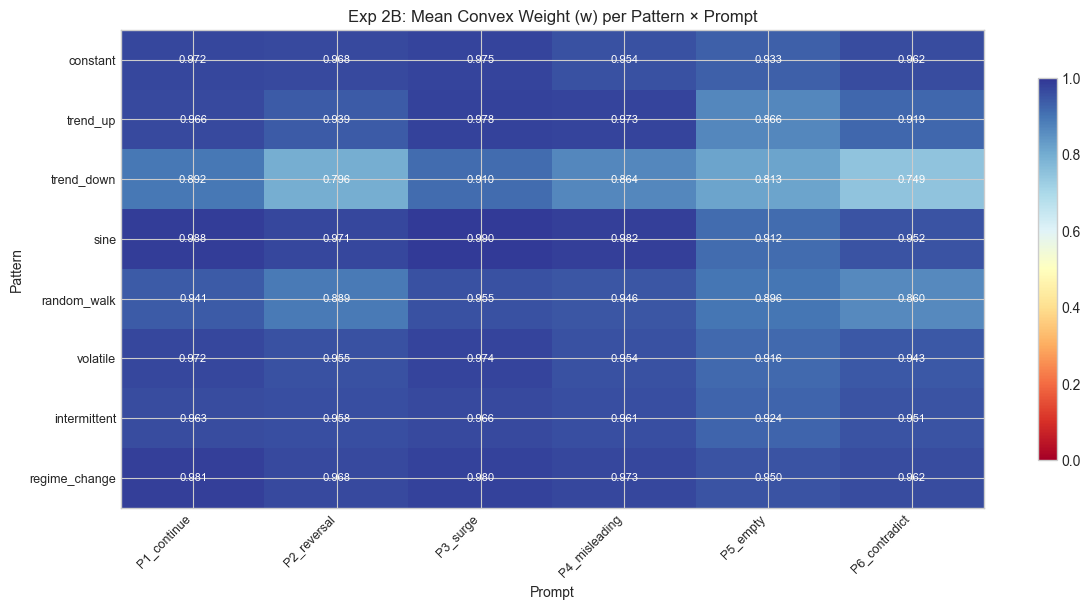

Mean w by pattern (higher = more Chronos trust):
regime_change   0.9691
sine            0.9657
constant        0.9606
intermittent    0.9537
volatile        0.9523
trend_up        0.9400
random_walk     0.9144
trend_down      0.8374

Mean w by prompt:
P1_continue     0.9593
P2_reversal     0.9305
P3_surge        0.9658
P4_misleading   0.9507
P5_empty        0.9010
P6_contradict   0.9124


In [8]:
# Mean convex weight per pattern × prompt
w_matrix = pd.DataFrame(index=SYNTHETIC_PATTERNS, columns=PROMPT_IDS, dtype=float)

for pat in SYNTHETIC_PATTERNS:
    for pid in PROMPT_IDS:
        w = all_results[(pat, pid)]["convex_weights"]
        w_matrix.loc[pat, pid] = w.mean()

fig, ax = plot_heatmap(w_matrix, title="Exp 2B: Mean Convex Weight (w) per Pattern × Prompt",
                       cmap="RdYlBu", fmt=".3f", vmin=0, vmax=1)
ax.set_xlabel("Prompt")
ax.set_ylabel("Pattern")
plt.show()

print("Mean w by pattern (higher = more Chronos trust):")
print(w_matrix.mean(axis=1).sort_values(ascending=False).to_string(float_format="{:.4f}".format))
print("\nMean w by prompt:")
print(w_matrix.mean(axis=0).to_string(float_format="{:.4f}".format))

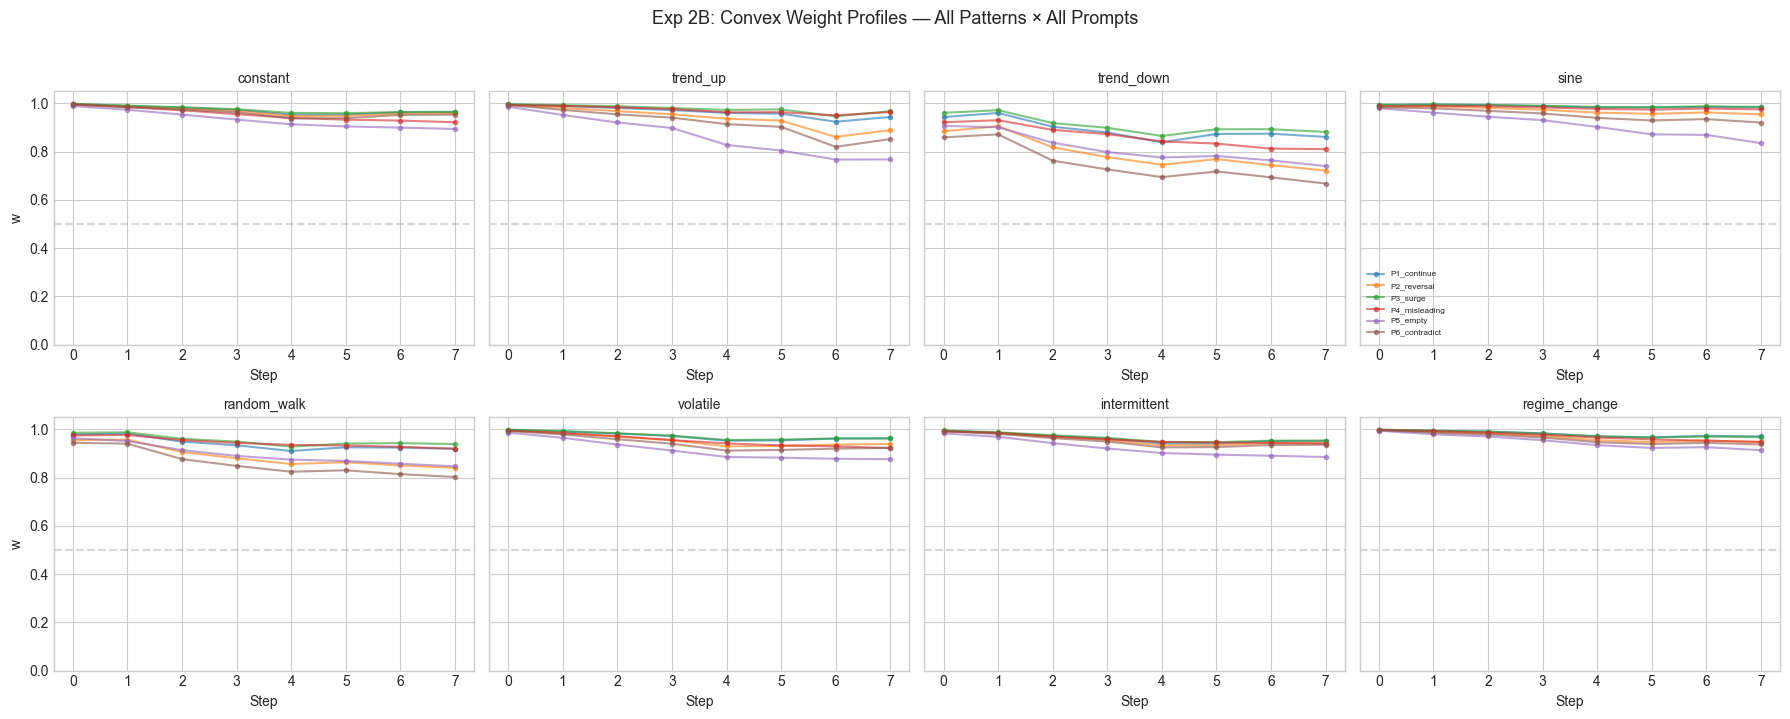

In [9]:
# Weight profiles (w vs. step) grouped by pattern — using P1 (continuation) prompt
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=True)
steps = np.arange(PRED_LEN)

for ax, pat in zip(axes.flat, SYNTHETIC_PATTERNS):
    for pid in PROMPT_IDS:
        w = all_results[(pat, pid)]["convex_weights"]
        ax.plot(steps, w, "o-", ms=3, alpha=0.6, label=pid)
    ax.set_title(pat, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", ls="--", alpha=0.3)
    ax.set_xlabel("Step")
    if ax in axes[:, 0]:
        ax.set_ylabel("w")

axes[0, -1].legend(fontsize=6, loc="lower left")
plt.suptitle("Exp 2B: Convex Weight Profiles — All Patterns × All Prompts", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Experiment 2C — Magnitude Sensitivity

For the **linear trend up** pattern, test predictive signals with increasing intensity:
- "slight increase" → "moderate increase" → "strong increase" → "extreme surge, 500% jump"

**Key question:** Is text influence monotonic with signal strength, or does it saturate?

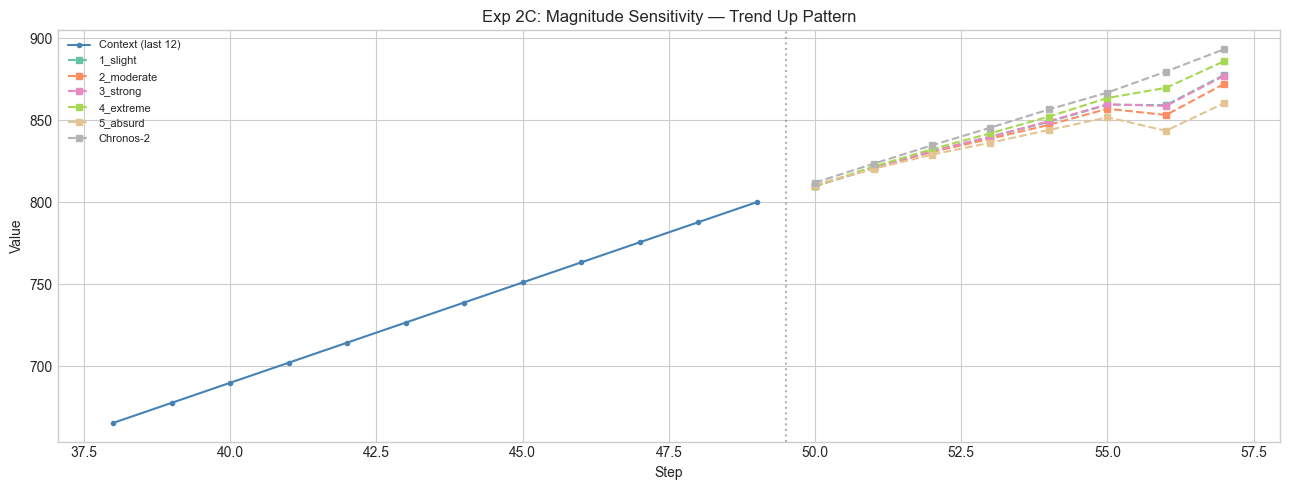

Intensity         Text Shift     Mean w   Forecast Mean
-------------------------------------------------------
1_slight                8.15     0.9705           843.4
2_moderate             10.30     0.9635           841.3
3_strong                8.14     0.9696           843.4
4_extreme               4.32     0.9815           847.3
5_absurd               14.49     0.9484           837.1


In [10]:
# Magnitude sensitivity on trend_up pattern
intensity_levels = {
    "1_slight":   "Slight increase expected, perhaps 5-10% above recent levels.",
    "2_moderate": "Moderate increase expected, around 20-30% above recent levels.",
    "3_strong":   "Strong increase expected. Project 50-80% increase from current levels.",
    "4_extreme":  "Extreme surge imminent. 200-300% increase from current levels expected.",
    "5_absurd":   "Unprecedented explosion. 500-1000% increase imminent. Historic surge.",
}

values_up = series_dict["trend_up"]
accurate_fact = describe_series(values_up)

mag_results = {}
for level, pred_text in intensity_levels.items():
    summary = build_summary(accurate_fact, pred_text)
    mag_results[level] = extractor.run(values_up, summary, pred_len=PRED_LEN)

chronos_fc = mag_results["1_slight"]["chronos_forecast"]

# Plot forecasts
mag_forecasts = {level: r["forecast"] for level, r in mag_results.items()}
mag_forecasts["Chronos-2"] = chronos_fc

fig, ax = plot_forecast_comparison(
    values_up, mag_forecasts,
    title="Exp 2C: Magnitude Sensitivity — Trend Up Pattern"
)
plt.show()

# Text shift vs intensity
print(f"{'Intensity':<15} {'Text Shift':>12} {'Mean w':>10} {'Forecast Mean':>15}")
print("-" * 55)
for level, r in mag_results.items():
    shift = text_shift(r["forecast"], chronos_fc)
    print(f"{level:<15} {shift:>12.2f} {r['convex_weights'].mean():>10.4f} {r['forecast'].mean():>15.1f}")

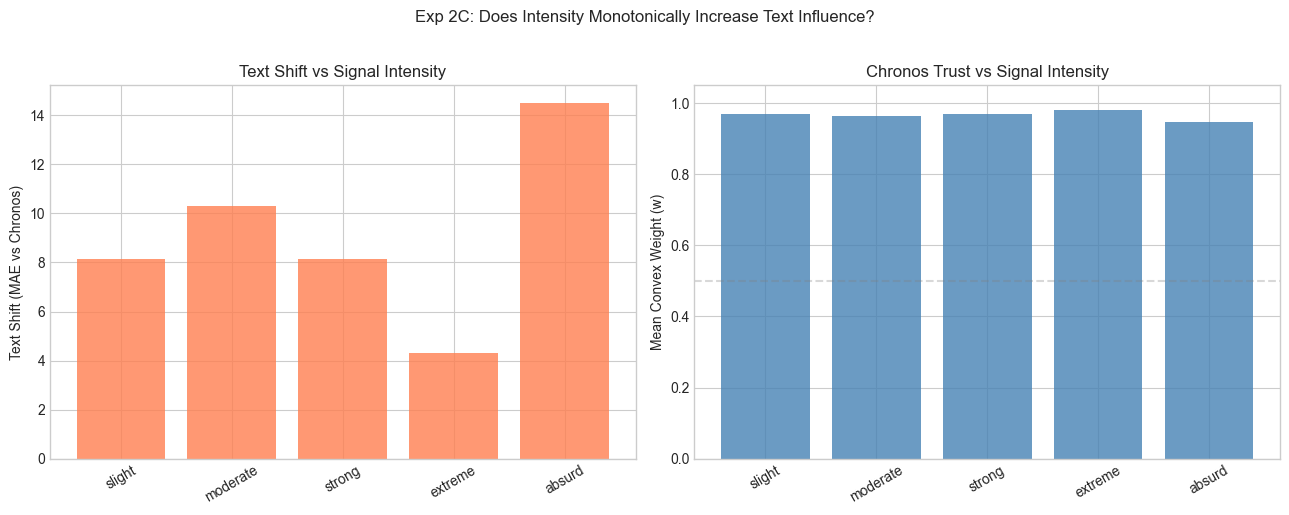

In [11]:
# Plot text_shift and mean w vs intensity level
levels = list(intensity_levels.keys())
shifts = [text_shift(mag_results[l]["forecast"], chronos_fc) for l in levels]
mean_w = [mag_results[l]["convex_weights"].mean() for l in levels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(range(len(levels)), shifts, color="coral", alpha=0.8)
ax1.set_xticks(range(len(levels)))
ax1.set_xticklabels([l.split("_")[1] for l in levels], rotation=30)
ax1.set_ylabel("Text Shift (MAE vs Chronos)")
ax1.set_title("Text Shift vs Signal Intensity")

ax2.bar(range(len(levels)), mean_w, color="steelblue", alpha=0.8)
ax2.set_xticks(range(len(levels)))
ax2.set_xticklabels([l.split("_")[1] for l in levels], rotation=30)
ax2.set_ylabel("Mean Convex Weight (w)")
ax2.set_ylim(0, 1.05)
ax2.axhline(0.5, color="gray", ls="--", alpha=0.3)
ax2.set_title("Chronos Trust vs Signal Intensity")

plt.suptitle("Exp 2C: Does Intensity Monotonically Increase Text Influence?", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Experiment 2D — Scale Sensitivity

Same pattern shape (trend up) at different value scales: **[0–1], [0–1000], [0–1M]**.

Since Migas normalizes inputs (zero-mean, unit-variance), the model *should* be scale-invariant. But do large numbers affect FinBERT embeddings (which see the factual text with actual numbers)?

In [12]:
# Scale sensitivity: same shape, different scales
SCALES = {"tiny (0-1)": 1.0, "normal (0-1K)": 1000.0, "large (0-1M)": 1_000_000.0}

scale_results = {}
for scale_name, scale_val in SCALES.items():
    values = generate_synthetic_series("trend_up", length=50, scale=scale_val)
    # P1 (accurate + continuation) and P3 (accurate + extreme surge)
    for pid in ["P1_continue", "P3_surge"]:
        fact = describe_series(values)
        pred = PREDICTIVE_TEXTS[pid]
        summary = build_summary(fact, pred)
        r = extractor.run(values, summary, pred_len=PRED_LEN)
        scale_results[(scale_name, pid)] = r

# Compare: normalized text_shift (as fraction of series mean)
print(f"{'Scale':<18} {'Prompt':<15} {'Text Shift':>12} {'Shift/Mean':>12} {'Mean w':>10}")
print("-" * 70)
for scale_name, scale_val in SCALES.items():
    values = generate_synthetic_series("trend_up", length=50, scale=scale_val)
    series_mean = values.mean()
    for pid in ["P1_continue", "P3_surge"]:
        r = scale_results[(scale_name, pid)]
        chronos_fc = r["chronos_forecast"]
        shift = text_shift(r["forecast"], chronos_fc)
        relative_shift = shift / series_mean if series_mean > 0 else 0
        print(f"{scale_name:<18} {pid:<15} {shift:>12.2f} {relative_shift:>12.4f} {r['convex_weights'].mean():>10.4f}")

Scale              Prompt            Text Shift   Shift/Mean     Mean w
----------------------------------------------------------------------
tiny (0-1)         P1_continue             0.01       0.0151     0.9706
tiny (0-1)         P3_surge                0.00       0.0064     0.9795
normal (0-1K)      P1_continue            10.10       0.0202     0.9656
normal (0-1K)      P3_surge                5.49       0.0110     0.9776
large (0-1M)       P1_continue         17918.93       0.0358     0.9377
large (0-1M)       P3_surge            14908.41       0.0298     0.9454


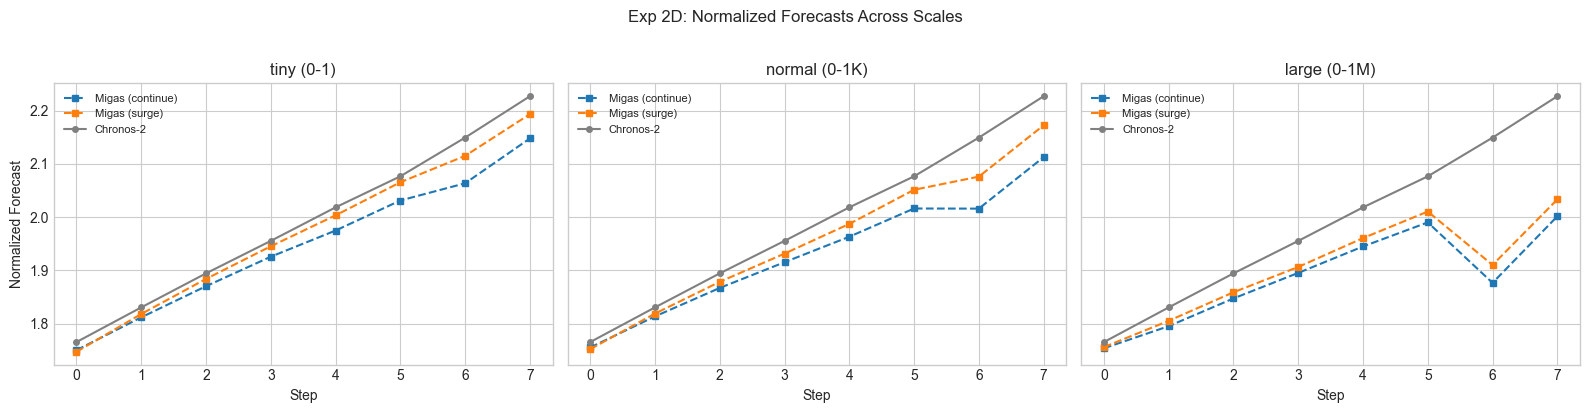

In [13]:
# Normalized forecast comparison across scales
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (scale_name, scale_val) in zip(axes, SCALES.items()):
    values = generate_synthetic_series("trend_up", length=50, scale=scale_val)
    mu, sigma = values.mean(), values.std()

    for pid in ["P1_continue", "P3_surge"]:
        r = scale_results[(scale_name, pid)]
        # Normalize forecast to compare shapes
        fc_norm = (r["forecast"] - mu) / (sigma + 1e-8)
        chronos_norm = (r["chronos_forecast"] - mu) / (sigma + 1e-8)
        ax.plot(fc_norm, "s--", ms=4, label=f"Migas ({pid.split('_')[1]})")

    chronos_fc = scale_results[(scale_name, "P1_continue")]["chronos_forecast"]
    chronos_norm = (chronos_fc - mu) / (sigma + 1e-8)
    ax.plot(chronos_norm, "o-", color="gray", ms=4, label="Chronos-2")
    ax.set_title(scale_name)
    ax.set_xlabel("Step")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Normalized Forecast")
plt.suptitle("Exp 2D: Normalized Forecasts Across Scales", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Experiment 2E — Context Length Sensitivity

Use the same sine pattern but vary context length: **10, 20, 30, 40, 50 steps**.

**Key question:** How does context length affect the balance between Chronos and text?

In [14]:
# Context length sensitivity on sine pattern
CTX_LENGTHS = [10, 20, 30, 40, 50]

ctx_results = {}
for ctx_len in CTX_LENGTHS:
    values = generate_synthetic_series("sine", length=ctx_len, scale=1000.0)
    for pid in ["P1_continue", "P3_surge", "P5_empty"]:
        fact = describe_series(values)
        pred = PREDICTIVE_TEXTS[pid]
        summary = build_summary(fact, pred) if pid != "P5_empty" else build_summary("", "")
        r = extractor.run(values, summary, pred_len=PRED_LEN)
        ctx_results[(ctx_len, pid)] = r
    print(f"  ctx_len={ctx_len}: done")

print(f"\nTotal runs: {len(ctx_results)}")

  ctx_len=10: done
  ctx_len=20: done
  ctx_len=30: done
  ctx_len=40: done
  ctx_len=50: done

Total runs: 15


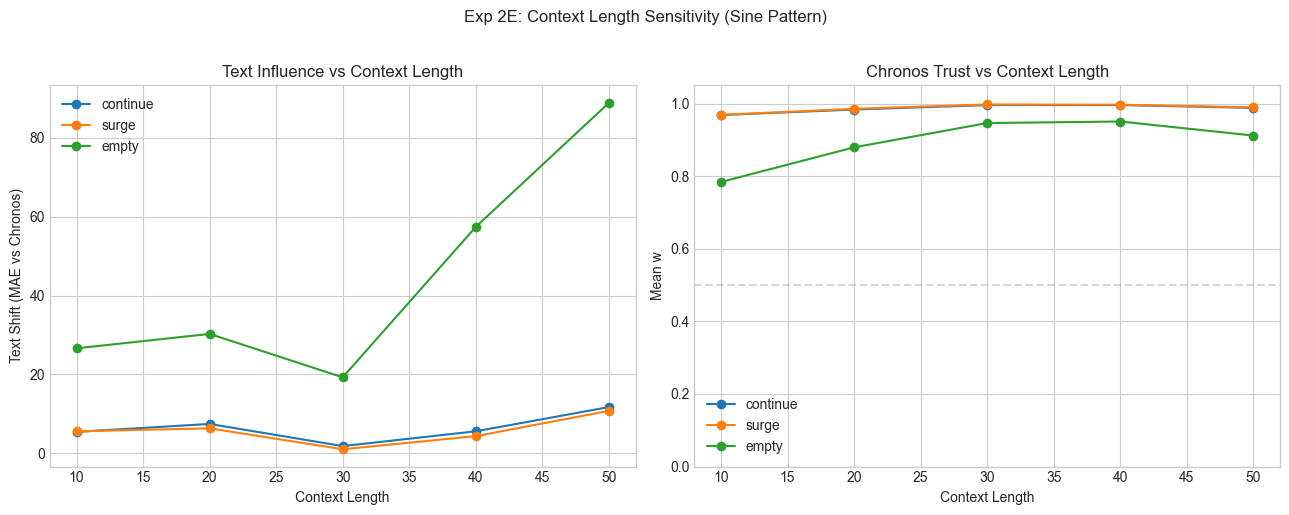

 Ctx Len Prompt            Text Shift     Mean w
--------------------------------------------------
      10 continue                5.39     0.9686
      10 surge                   5.53     0.9692
      10 empty                  26.61     0.7842
      20 continue                7.41     0.9837
      20 surge                   6.29     0.9856
      20 empty                  30.26     0.8796
      30 continue                1.78     0.9960
      30 surge                   0.98     0.9977
      30 empty                  19.24     0.9465
      40 continue                5.54     0.9961
      40 surge                   4.32     0.9970
      40 empty                  57.45     0.9508
      50 continue               11.69     0.9882
      50 surge                  10.74     0.9896
      50 empty                  88.93     0.9120


In [15]:
# Text shift and mean w vs context length
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for pid in ["P1_continue", "P3_surge", "P5_empty"]:
    shifts = []
    weights = []
    for ctx_len in CTX_LENGTHS:
        r = ctx_results[(ctx_len, pid)]
        chronos_fc = r["chronos_forecast"]
        shifts.append(text_shift(r["forecast"], chronos_fc))
        weights.append(r["convex_weights"].mean())

    label = pid.split("_")[1]
    ax1.plot(CTX_LENGTHS, shifts, "o-", ms=6, label=label)
    ax2.plot(CTX_LENGTHS, weights, "o-", ms=6, label=label)

ax1.set_xlabel("Context Length")
ax1.set_ylabel("Text Shift (MAE vs Chronos)")
ax1.set_title("Text Influence vs Context Length")
ax1.legend()

ax2.set_xlabel("Context Length")
ax2.set_ylabel("Mean w")
ax2.set_ylim(0, 1.05)
ax2.axhline(0.5, color="gray", ls="--", alpha=0.3)
ax2.set_title("Chronos Trust vs Context Length")
ax2.legend()

plt.suptitle("Exp 2E: Context Length Sensitivity (Sine Pattern)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Ctx Len':>8} {'Prompt':<15} {'Text Shift':>12} {'Mean w':>10}")
print("-" * 50)
for ctx_len in CTX_LENGTHS:
    for pid in ["P1_continue", "P3_surge", "P5_empty"]:
        r = ctx_results[(ctx_len, pid)]
        shift = text_shift(r["forecast"], r["chronos_forecast"])
        print(f"{ctx_len:>8} {pid.split('_')[1]:<15} {shift:>12.2f} {r['convex_weights'].mean():>10.4f}")

## Summary of Key Findings

<!-- Run this notebook and fill in observations below:

### Exp 2A — Text Sensitivity Matrix
- **Most sensitive pattern:** ___ (highest text_shift)
- **Least sensitive pattern:** ___ (lowest text_shift)
- **Most impactful prompt:** ___ (P1–P6)
- **Pattern-prompt interaction:** Does the same prompt have different effects on different patterns?

### Exp 2B — Convex Weight Patterns
- **Highest w (most Chronos trust):** ___ pattern
- **Lowest w (most text trust):** ___ pattern
- **Do weights vary across steps?** (flat vs. changing profile)
- **Do weights vary with prompt?** (same pattern, different text)

### Exp 2C — Magnitude Sensitivity
- **Is text influence monotonic?** ___ (yes/no/saturates)
- **Saturation point:** ___ (if applicable)
- **Does w change with intensity?** ___

### Exp 2D — Scale Sensitivity
- **Scale-invariant?** ___ (yes/no)
- **Relative text_shift consistent across scales?** ___
- **Does the factual description (with actual numbers) affect FinBERT differently at different scales?** ___

### Exp 2E — Context Length Sensitivity
- **Does more context increase Chronos trust (higher w)?** ___
- **Does text influence diminish with more context?** ___
- **Minimum context for stable behavior:** ___ steps
-->